In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re

ROOT = Path("../results/20260507_233056_balanced/consumer/")
#files = sorted (ROOT.glob("consumer_metrics_2026-04-19-11-27_consumer-sts-0.csv"))
files = sorted(ROOT.glob("consumer-sts-*_metrics/2026-05-07-23-06//per_message_latency_*_consumer-sts-*.csv"))
#files = sorted(ROOT.glob("consumer-sts-*_metrics/2026-05-07-23-06//consumer_partition_lag_*_consumer-sts-*.csv"))



def read_one(fpath: Path) -> pd.DataFrame:
    df1 = pd.read_csv(fpath)
    
    # Your per-message schema should include these
    needed = {"recv_ts","producer_ts","e2e_ms","topic","partition","offset","producer_pod","index"}
    missing = needed - set(df1.columns)
    if missing:
        raise ValueError(f"{fpath.name} missing columns: {missing}")

    m = re.search(r"(consumer-sts-\d+)", fpath.name)
    df1["consumer_pod"] = m.group(1) if m else "unknown"

    # types
    df1["recv_ts"] = pd.to_numeric(df1["recv_ts"], errors="coerce")
    df1["producer_ts"] = pd.to_numeric(df1["producer_ts"], errors="coerce")
    df1["e2e_ms"] = pd.to_numeric(df1["e2e_ms"], errors="coerce")
    df1["partition"] = pd.to_numeric(df1["partition"], errors="coerce").astype("Int64")
    df1["offset"] = pd.to_numeric(df1["offset"], errors="coerce").astype("Int64")

    df1 = df1.dropna(subset=["recv_ts","producer_ts","e2e_ms"])
    return df1

df = pd.concat([read_one(f) for f in files], ignore_index=True)


print("Total sampled messages:", len(df), "pods:", df["consumer_pod"].nunique())

print(df.head())
df.shape[0]


Total sampled messages: 29462 pods: 5
        recv_ts   producer_ts        e2e_ms                            topic  \
0  1.777596e+09  1.777596e+09  40754.266262  B0-skew-R1500-20260430-183753_0   
1  1.777596e+09  1.777596e+09  34761.058807  B0-skew-R1500-20260430-183753_0   
2  1.777596e+09  1.777596e+09  36597.175121  B0-skew-R1500-20260430-183753_0   
3  1.777596e+09  1.777596e+09   5829.907417  B0-skew-R1500-20260430-183753_0   
4  1.777596e+09  1.777596e+09  13165.009737  B0-skew-R1500-20260430-183753_0   

   partition  offset    producer_pod  index    consumer_pod  
0         31      27  producer-sts-1  17283  consumer-sts-0  
1         31      50  producer-sts-1  20948  consumer-sts-0  
2         25      39  producer-sts-1  19826  consumer-sts-0  
3         25     131  producer-sts-0  10948  consumer-sts-0  
4         37       8  producer-sts-0   9048  consumer-sts-0  


29462

In [27]:
pod_summary = (
    df.groupby("consumer_pod", as_index=False)
       .agg(
           n=("e2e_ms", "size"),
           p50_ms=("e2e_ms", lambda x: float(x.quantile(0.50))),
           p95_ms=("e2e_ms", lambda x: float(x.quantile(0.95))),
           p99_ms=("e2e_ms", lambda x: float(x.quantile(0.99))),  
           max_ms=("e2e_ms", "max"),
       )
       .sort_values("p99_ms", ascending=False)
)

pod_summary

,consumer_pod,n,p50_ms,p95_ms,p99_ms,max_ms
0,consumer-sts-0,11087,89.703560,31462.330317,106750.230923,156713.754416
1,consumer-sts-1,6445,92.912912,14894.454861,69917.652559,104483.659983
3,consumer-sts-3,1891,96.903801,32993.823171,54023.898387,110417.766809
2,consumer-sts-2,1324,104.241610,17676.996684,52934.274364,126076.680422
4,consumer-sts-4,8715,90.784311,12416.588545,39780.303769,121183.224678


In [28]:
s = df["e2e_ms"].to_numpy()

cluster_summary = {
    "n": len(s),
    "p50_ms": np.quantile(s, 0.50),
    "p95_ms": np.quantile(s, 0.95),
    "p99_ms": np.quantile(s, 0.99),
    #"p999_ms": np.quantile(s, 0.999) if len(arr) >= 1000 else np.nan,
    "max_ms": float(np.max(s)),
}
cluster_summary


{'n': 29462,
 'p50_ms': 91.76135063171387,
 'p95_ms': 20155.142939090718,
 'p99_ms': 75154.21732902496,
 'max_ms': 156713.75441551208}

In [43]:
# Remove base latency (network + processing)

baseline = df["e2e_ms"].quantile(0.05)

df["queue_delay"] = df["e2e_ms"] - baseline
df["queue_delay"] = df["queue_delay"].clip(lower=0)

## Identify HOT partitions

hot_partitions = (
    df.groupby("partition")["queue_delay"]
    .mean()
    .sort_values(ascending=False)
)

print(hot_partitions.head(20))
hot = hot_partitions.index[0]

partition
20    7276.408241
8     6965.033517
13    6438.633672
56    5980.520922
37    5767.206383
55    5700.064744
39    5155.116600
49    4826.669674
52    4683.940095
11    4591.733599
24    4561.601659
25    4244.066354
42    3877.685837
28    3827.161898
0     3677.772034
47    3551.868580
17    3537.650177
7     3502.926831
50    3497.850746
59    3316.266842
Name: queue_delay, dtype: float64


In [44]:
df["time_bucket"] = (df["recv_ts"] // 1).astype(int)   # 1-second buckets
bucket = df.groupby(["time_bucket", "partition"])["queue_delay"].mean().reset_index()
pivot = bucket.pivot(index="time_bucket", columns="partition", values="queue_delay")
#pivot = pivot.fillna(method="ffill").fillna(0)

In [45]:
pivot_filled = pivot.fillna(method="ffill").fillna(0)
                                                                                                                                                                        

hot = pivot_filled.columns[0]  #  detected hot

results = []

for p in pivot_filled.columns:
    if p == hot:
        continue

    corr = pivot_filled[hot].corr(pivot_filled[p])
    results.append((p, corr))

print(sorted(results, key=lambda x: abs(x[1]), reverse=True)[:10])

[(58, 0.2053153638417152), (47, 0.15904622141529323), (40, 0.15235597225593225), (17, 0.12074087461928748), (14, 0.11706563508012759), (8, 0.1024157543696534), (21, 0.10163836017493276), (32, 0.09969143352359615), (28, 0.09709876471456572), (33, 0.08462713229830203)]


In [46]:
throughput = df.groupby("time_bucket").size()
combined = pd.DataFrame({
    "hot_delay": pivot_filled[hot],
    "throughput": throughput
}).dropna()

print(combined.corr())

            hot_delay  throughput
hot_delay    1.000000    0.695928
throughput   0.695928    1.000000


In [50]:
ROOT = Path("../results/20260503_160842_skew/consumer/")
lag_files = sorted(ROOT.glob("consumer-sts-*_metrics/2026-04-30-18-38/consumer_partition_lag_*_consumer-sts-*.csv"))

def read_one(fpath: Path) -> pd.DataFrame:
    df1 = pd.read_csv(fpath)
    
    # Your per-message schema should include these
    needed = {"ts_epoch","partition","lag"}
    missing = needed - set(df1.columns)
    if missing:
        raise ValueError(f"{fpath.name} missing columns: {missing}")

    m = re.search(r"(consumer-sts-\d+)", fpath.name)
    df1["consumer_pod"] = m.group(1) if m else "unknown"

    # types
    df1["ts_epoch"] = pd.to_numeric(df1["ts_epoch"], errors="coerce")
    #df1["pod"] = pd.to_numeric(df1["pod"], errors="coerce")
    #df1["topic"] = pd.to_numeric(df1["topic"], errors="coerce")
    df1["partition"] = df1["partition"].astype("Int64")
    df1["lag"] = pd.to_numeric(df1["lag"], errors="coerce")
    df1["time_bucket"] = df1["ts_epoch"].round().astype(int)

    #df1 = df1.dropna(subset=["recv_ts","producer_ts","e2e_ms"])
    return df1

lag = pd.concat([read_one(f) for f in lag_files], ignore_index=True)
#print("Total sampled messages:", len(df), "pods:", df["consumer_pod"].nunique())

print(lag.head())
lag.shape[0]


       ts_epoch             pod traffic_mode                            topic  \
0  1.777596e+09  consumer-sts-0         skew  B0-skew-R1500-20260430-183753_0   
1  1.777596e+09  consumer-sts-0         skew  B0-skew-R1500-20260430-183753_0   
2  1.777596e+09  consumer-sts-0         skew  B0-skew-R1500-20260430-183753_0   
3  1.777596e+09  consumer-sts-0         skew  B0-skew-R1500-20260430-183753_0   
4  1.777596e+09  consumer-sts-0         skew  B0-skew-R1500-20260430-183753_0   

   partition  current_offset  high_watermark  lag    consumer_pod  time_bucket  
0          1             130             130    0  consumer-sts-0   1777595992  
1          7              51              51    0  consumer-sts-0   1777595992  
2         13              20              20    0  consumer-sts-0   1777595992  
3         19              28              28    0  consumer-sts-0   1777595992  
4         25             169             170    1  consumer-sts-0   1777595992  


406718

In [53]:
pivot_lag = lag.pivot_table(
    index="time_bucket",
    columns="partition",
    values="lag",
    aggfunc="mean"
).sort_index()
pivot_lag= pivot_lag.fillna(method="ffill").fillna(0)
pivot_diff = pivot_lag.diff().dropna()

hot_partition = pivot_lag.mean().idxmax()
print("Hot partition:", hot_partition)
corrs = []

for p in pivot_diff.columns:
    if p == hot_partition:
        continue

    c = pivot_diff[hot].corr(pivot_diff[p])
    corrs.append((p, c))

print(sorted(corrs, key=lambda x: abs(x[1]), reverse=True)[:10])

Hot partition: 0
[(10, 0.251555634767269), (40, 0.16207142520280096), (29, 0.14907534875173276), (23, -0.10241498050723352), (17, -0.0993309773618971), (2, -0.09764877234251415), (50, 0.09386432173802917), (27, -0.09258747380079947), (42, 0.07341362905704746), (59, 0.0733009122427666)]


In [52]:
lagged_corrs = []

for p in pivot_lag.columns:
    if p == hot_partition:
        continue

    c = pivot_lag[hot_partition].shift(1).corr(pivot[p])
    lagged_corrs.append((p, c))

print(sorted(lagged_corrs, key=lambda x: abs(x[1]), reverse=True)[:10])

[(33, 0.9863261997939204), (47, 0.9444337166295605), (52, 0.8485763610030594), (42, 0.8160764616490135), (40, 0.8054856489828969), (13, 0.7599597391764891), (32, 0.7157620538217198), (8, 0.6022802499960073), (36, 0.5159505363023065), (19, 0.49687745045450993)]


In [70]:
plt.scatter(df["total_lag"], df["lat_p99_ms"])
plt.xlabel("Total Lag")
plt.ylabel("P99 Latency (ms)")
plt.title("Lag vs Latency")
plt.show()

KeyError: 'total_lag'

In [6]:
print(df[["total_lag", "lat_p99_ms"]].corr())


            total_lag  lat_p99_ms
total_lag    1.000000   -0.014569
lat_p99_ms  -0.014569    1.000000


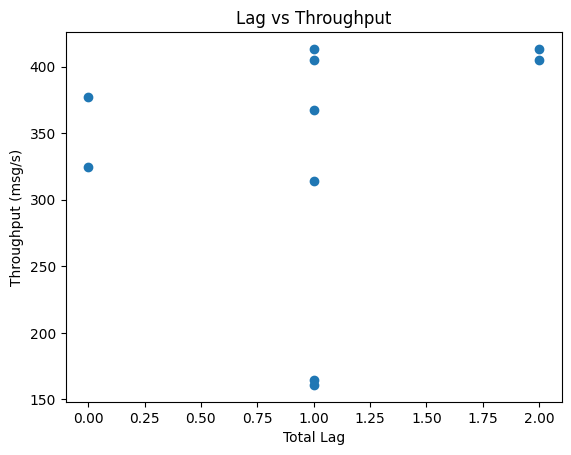

In [7]:
plt.scatter(df["total_lag"], df["msg_rate_window"])
plt.xlabel("Total Lag")
plt.ylabel("Throughput (msg/s)")
plt.title("Lag vs Throughput")
plt.show()

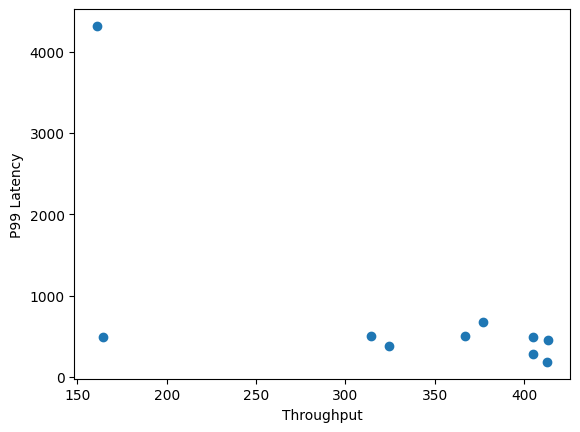

In [8]:
plt.scatter(df["msg_rate_window"], df["lat_p99_ms"])
plt.xlabel("Throughput")
plt.ylabel("P99 Latency")
plt.show()

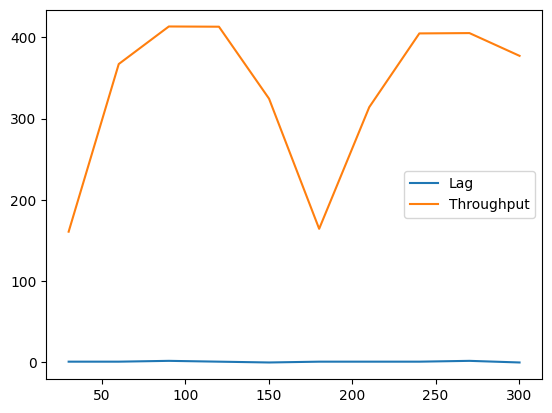

In [9]:
plt.plot(df["uptime_sec"], df["total_lag"], label="Lag")
plt.plot(df["uptime_sec"], df["msg_rate_window"], label="Throughput")
plt.legend()
plt.show()

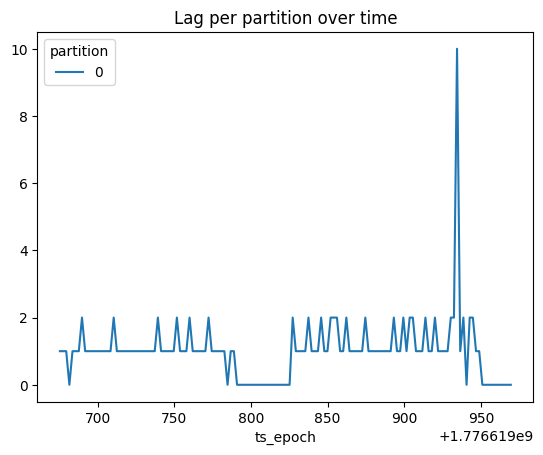

In [10]:

dfp = pd.read_csv("../results/20260430_162503_skew/consumer/consumer-sts-0_metrics/2026-04-19-11-27/consumer_partition_lag_2026-04-19-11-27_consumer-sts-0.csv")

pivot = dfp.pivot_table(
    index="ts_epoch",
    columns="partition",
    values="lag"
)

pivot.plot()
plt.title("Lag per partition over time")
plt.show()

In [11]:
pivot["p0_lag_shifted"] = pivot[0].shift(1)

corr = pivot[[1, "p0_lag_shifted"]].corr()
print(corr)

KeyError: '[1] not in index'